In [ ]:
from pathlib import Path
from collections import Counter, defaultdict
import csv
import hashlib
import random
import shutil
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


DATASET_SOURCES = [
    {
        "name": "AOD4",
        "root": Path(r"F:\kurs_work\AOD 4\AOD 4"),
        "layout": "aod4",
        "enabled": True,
    },
    {
        "name": "RoboflowDrone_v26",
        "root": Path(r"F:\kurs_work\datasetDrone.v26i.yolov8"),
        "layout": "roboflow",
        "enabled": True,
    },
    {
        "name": "RoboflowDrone_v25",
        "root": Path(r"F:\kurs_work\datasetDrone.v26i.yolov8"),
        "layout": "roboflow",
        "enabled": False,
    },
]

MERGED_ROOT = Path(r"F:\kurs_work\processed\merged_airborne")
ANALYSIS_DIR = MERGED_ROOT / "analysis"

SPLITS = ["train", "valid", "test"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Итоговая общая схема классов.
CANONICAL_NAMES = {
    0: "airplane",
    1: "bird",
    2: "drone",
    3: "helicopter",
}

# Алиасы нужны, потому что Roboflow часто пишет Drone/drone/UAV и т.п.
NAME_TO_CANONICAL_ID = {
    "airplane": 0, "plane": 0, "aircraft": 0,
    "bird": 1, "birds": 1,
    "drone": 2, "drones": 2, "uav": 2, "uas": 2,
    "helicopter": 3, "heli": 3,
}

In [ ]:


def ensure_empty_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def get_all_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def find_image_by_stem(folder: Path, stem: str):
    for ext in IMAGE_EXTENSIONS:
        candidate = folder / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    for p in folder.glob(stem + ".*"):
        if p.suffix.lower() in IMAGE_EXTENSIONS:
            return p
    return None


def file_sha1(path: Path, block_size=1024 * 1024):
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def resolve_dirs(dataset_root: Path, layout: str, split: str):
    """Возвращает папки images и labels для заданного split."""
    if layout == "aod4":
        image_dir = dataset_root / "Images" / split
        label_dir = dataset_root / "Annotations" / "YOLOv8 format" / split / "labels"
        return image_dir, label_dir

    if layout == "roboflow":
        # Roboflow export обычно: train/images, train/labels, valid/images, valid/labels.
        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"
        return image_dir, label_dir

    if layout == "standard_yolo":
        image_dir = dataset_root / "images" / split
        label_dir = dataset_root / "labels" / split
        return image_dir, label_dir

    raise ValueError(f"Неизвестный layout: {layout}")


def read_source_names(dataset_root: Path, fallback_names=None):
    """Читает names из data.yaml, если он есть."""
    fallback_names = fallback_names or CANONICAL_NAMES
    yaml_candidates = [dataset_root / "data.yaml", dataset_root / "dataset.yaml"]
    for yml in yaml_candidates:
        if yml.exists():
            with open(yml, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f) or {}
            names = data.get("names", fallback_names)
            if isinstance(names, list):
                return {i: str(name) for i, name in enumerate(names)}
            if isinstance(names, dict):
                return {int(k): str(v) for k, v in names.items()}
    return fallback_names.copy()


def map_class_id(source_class_id: int, source_names: dict):
    source_name = str(source_names.get(source_class_id, f"class_{source_class_id}")).strip().lower()
    if source_name in NAME_TO_CANONICAL_ID:
        return NAME_TO_CANONICAL_ID[source_name]
    if source_class_id in CANONICAL_NAMES and source_name == CANONICAL_NAMES[source_class_id]:
        return source_class_id
    raise ValueError(
        f"Не удалось сопоставить класс {source_class_id}='{source_name}' с общей схемой. "
        f"Добавь его в NAME_TO_CANONICAL_ID."
    )


def parse_yolo_line(parts):
    """Поддерживает bbox: cls xc yc w h и polygon: cls x1 y1 x2 y2 ..."""
    class_id = int(float(parts[0]))

    if len(parts) == 5:
        xc, yc, bw, bh = map(float, parts[1:])
        source_format = "bbox"
    elif len(parts) > 5 and (len(parts) - 1) % 2 == 0:
        coords = list(map(float, parts[1:]))
        xs = coords[0::2]
        ys = coords[1::2]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        xc = (x_min + x_max) / 2
        yc = (y_min + y_max) / 2
        bw = x_max - x_min
        bh = y_max - y_min
        source_format = "polygon_converted_to_bbox"
    else:
        raise ValueError(f"неизвестный формат: {len(parts)} значений")

    return class_id, xc, yc, bw, bh, source_format


def parse_yolo_label(label_path: Path, source_names: dict):
    objects = []
    errors = []

    if not label_path.exists():
        return objects, errors

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line_number, line in enumerate(lines, start=1):
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        try:
            source_class_id, xc, yc, bw, bh, source_format = parse_yolo_line(parts)
            class_id = map_class_id(source_class_id, source_names)
        except Exception as e:
            errors.append(f"{label_path}, строка {line_number}: {e}")
            continue

        values = [xc, yc, bw, bh]
        if not all(0 <= v <= 1 for v in values):
            errors.append(f"{label_path}, строка {line_number}: координаты вне [0; 1]")
        if bw <= 0 or bh <= 0:
            errors.append(f"{label_path}, строка {line_number}: ширина/высота <= 0")

        x_min = xc - bw / 2
        y_min = yc - bh / 2
        x_max = xc + bw / 2
        y_max = yc + bh / 2
        if x_min < -1e-6 or y_min < -1e-6 or x_max > 1 + 1e-6 or y_max > 1 + 1e-6:
            errors.append(f"{label_path}, строка {line_number}: bbox выходит за границы")

        # Подрезаем микровыходы из-за округления.
        xc = min(max(xc, 0.0), 1.0)
        yc = min(max(yc, 0.0), 1.0)
        bw = min(max(bw, 0.0), 1.0)
        bh = min(max(bh, 0.0), 1.0)

        objects.append({
            "class_id": class_id,
            "xc": xc,
            "yc": yc,
            "w": bw,
            "h": bh,
            "source_format": source_format,
        })

    return objects, errors


def write_yolo_label(label_path: Path, objects):
    label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(label_path, "w", encoding="utf-8") as f:
        for obj in objects:
            f.write(f"{obj['class_id']} {obj['xc']:.6f} {obj['yc']:.6f} {obj['w']:.6f} {obj['h']:.6f}\n")


def size_category(relative_area):
    # Шкала подобрана под воздушные объекты: много очень мелких bbox.
    if relative_area < 0.01:
        return "tiny"
    if relative_area < 0.05:
        return "small"
    if relative_area < 0.20:
        return "medium"
    return "large"

In [ ]:


ensure_empty_dir(MERGED_ROOT)
for split in SPLITS:
    (MERGED_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (MERGED_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

manifest_rows = []
errors = []
seen_hashes = set()

for source in DATASET_SOURCES:
    if not source.get("enabled", False):
        continue

    source_name = source["name"]
    source_root = Path(source["root"])
    layout = source["layout"]
    source_names = read_source_names(source_root)

    print(f"\nИсточник: {source_name}")
    print(f"root: {source_root}")
    print(f"classes: {source_names}")

    for split in SPLITS:
        image_dir, label_dir = resolve_dirs(source_root, layout, split)
        images = get_all_images(image_dir)
        print(f"  {split}: изображений={len(images)}, image_dir={image_dir}")

        if not image_dir.exists():
            errors.append(f"Не найдена папка изображений: {image_dir}")
            continue
        if not label_dir.exists():
            errors.append(f"Не найдена папка labels: {label_dir}")
            continue

        for img_path in images:
            img_hash = file_sha1(img_path)
            is_exact_duplicate = img_hash in seen_hashes
            if is_exact_duplicate:
                manifest_rows.append({
                    "source": source_name,
                    "split": split,
                    "original_image": str(img_path),
                    "merged_image": "",
                    "duplicate_skipped": 1,
                    "objects": 0,
                })
                continue
            seen_hashes.add(img_hash)

            label_path = label_dir / f"{img_path.stem}.txt"
            objects, label_errors = parse_yolo_label(label_path, source_names)
            errors.extend(label_errors)

            new_stem = f"{source_name}__{img_path.stem}"
            dst_img = MERGED_ROOT / "images" / split / f"{new_stem}{img_path.suffix.lower()}"
            dst_lbl = MERGED_ROOT / "labels" / split / f"{new_stem}.txt"

            shutil.copy2(img_path, dst_img)
            write_yolo_label(dst_lbl, objects)

            manifest_rows.append({
                "source": source_name,
                "split": split,
                "original_image": str(img_path),
                "merged_image": str(dst_img),
                "duplicate_skipped": 0,
                "objects": len(objects),
            })

with open(MERGED_ROOT / "data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump({
        "path": str(MERGED_ROOT),
        "train": "images/train",
        "val": "images/valid",
        "test": "images/test",
        "names": CANONICAL_NAMES,
    }, f, allow_unicode=True, sort_keys=False)

pd.DataFrame(manifest_rows).to_csv(ANALYSIS_DIR / "merge_manifest.csv", index=False, sep=";", encoding="utf-8-sig")
pd.DataFrame({"error": errors}).to_csv(ANALYSIS_DIR / "merge_errors.csv", index=False, sep=";", encoding="utf-8-sig")

print("\nГотово.")
print("MERGED_ROOT:", MERGED_ROOT)
print("Ошибок:", len(errors))
print(pd.DataFrame(manifest_rows).groupby(["source", "split"])["merged_image"].count())


Источник: AOD4
root: F:\kurs_work\AOD 4\AOD 4
classes: {0: 'airplane', 1: 'bird', 2: 'drone', 3: 'helicopter'}
  train: изображений=15761, image_dir=F:\kurs_work\AOD 4\AOD 4\Images\train
  valid: изображений=4514, image_dir=F:\kurs_work\AOD 4\AOD 4\Images\valid
  test: изображений=2241, image_dir=F:\kurs_work\AOD 4\AOD 4\Images\test

Источник: RoboflowDrone_v26
root: F:\kurs_work\datasetDrone.v26i.yolov8
classes: {0: 'Airplane', 1: 'Bird', 2: 'Drone', 3: 'Helicopter'}
  train: изображений=5361, image_dir=F:\kurs_work\datasetDrone.v26i.yolov8\train\images
  valid: изображений=766, image_dir=F:\kurs_work\datasetDrone.v26i.yolov8\valid\images
  test: изображений=717, image_dir=F:\kurs_work\datasetDrone.v26i.yolov8\test\images

Готово.
MERGED_ROOT: F:\kurs_work\processed\merged_airborne
Ошибок: 0
source             split
AOD4               test      2241
                   train    15761
                   valid     4514
RoboflowDrone_v26  test       717
                   train     5361


In [ ]:
  
image_rows = []
bbox_rows = []
stat_errors = []
empty_labels = []
missing_labels = []

for split in SPLITS:
    image_dir = MERGED_ROOT / "images" / split
    label_dir = MERGED_ROOT / "labels" / split
    images = get_all_images(image_dir)

    for img_path in images:
        label_path = label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            missing_labels.append(str(img_path))
            objects = []
        else:
            objects, errs = parse_yolo_label(label_path, CANONICAL_NAMES)
            stat_errors.extend(errs)

        try:
            with Image.open(img_path) as im:
                image_width, image_height = im.size
        except Exception as e:
            stat_errors.append(f"Не удалось открыть {img_path}: {e}")
            continue

        if label_path.exists() and len(objects) == 0:
            empty_labels.append(str(label_path))

        image_rows.append({
            "split": split,
            "image_name": img_path.name,
            "image_width": image_width,
            "image_height": image_height,
            "objects_count": len(objects),
        })

        for obj in objects:
            bbox_width_px = obj["w"] * image_width
            bbox_height_px = obj["h"] * image_height
            bbox_area_px = bbox_width_px * bbox_height_px
            image_area_px = image_width * image_height
            relative_area = bbox_area_px / image_area_px if image_area_px > 0 else 0
            aspect_ratio = bbox_width_px / bbox_height_px if bbox_height_px > 0 else 0

            bbox_rows.append({
                "split": split,
                "image_name": img_path.name,
                "class_id": obj["class_id"],
                "class_name": CANONICAL_NAMES[obj["class_id"]],
                "image_width": image_width,
                "image_height": image_height,
                "bbox_width_px": bbox_width_px,
                "bbox_height_px": bbox_height_px,
                "bbox_area_px": bbox_area_px,
                "relative_area": relative_area,
                "aspect_ratio": aspect_ratio,
                "size_category": size_category(relative_area),
                "source_format": obj.get("source_format", "bbox"),
            })

images_df = pd.DataFrame(image_rows)
bbox_df = pd.DataFrame(bbox_rows)

images_df.to_csv(ANALYSIS_DIR / "images_stats.csv", index=False, sep=";", encoding="utf-8-sig")
bbox_df.to_csv(ANALYSIS_DIR / "bbox_stats.csv", index=False, sep=";", encoding="utf-8-sig")
pd.DataFrame({"error": stat_errors}).to_csv(ANALYSIS_DIR / "stat_errors.csv", index=False, sep=";", encoding="utf-8-sig")
pd.DataFrame({"label_path": empty_labels}).to_csv(ANALYSIS_DIR / "empty_labels.csv", index=False, sep=";", encoding="utf-8-sig")

split_summary = images_df.groupby("split").agg(
    images=("image_name", "count"),
    empty_images=("objects_count", lambda s: int((s == 0).sum())),
    mean_objects=("objects_count", "mean"),
    max_objects=("objects_count", "max"),
).reset_index()

class_summary = pd.pivot_table(
    bbox_df,
    index="class_name",
    columns="split",
    values="image_name",
    aggfunc="count",
    fill_value=0,
).reset_index()
class_summary["total"] = class_summary[[c for c in class_summary.columns if c != "class_name"]].sum(axis=1)

size_summary = pd.pivot_table(
    bbox_df,
    index="class_name",
    columns="size_category",
    values="image_name",
    aggfunc="count",
    fill_value=0,
).reset_index()
size_cols = [c for c in ["tiny", "small", "medium", "large"] if c in size_summary.columns]
size_summary["total"] = size_summary[size_cols].sum(axis=1)

print("Split summary")
display(split_summary)
print("Class summary")
display(class_summary)
print("Size summary")
display(size_summary)
print(f"Пустых labels: {len(empty_labels)}; ошибок: {len(stat_errors)}")

Split summary


,split,images,empty_images,mean_objects,max_objects
0,test,2936,56,1.334809,35
1,train,21094,415,1.322983,36
2,valid,5274,125,1.365377,36


Class summary


split,class_name,test,train,valid,total
0,airplane,820,6046,1709,8575
1,bird,918,6395,1666,8979
2,drone,1304,9134,2117,12555
3,helicopter,877,6332,1709,8918


Size summary


size_category,class_name,large,medium,small,tiny,total
0,airplane,1285,1578,2344,3368,8575
1,bird,889,1303,2143,4644,8979
2,drone,566,646,2020,9323,12555
3,helicopter,1269,1687,3296,2666,8918


Пустых labels: 596; ошибок: 0


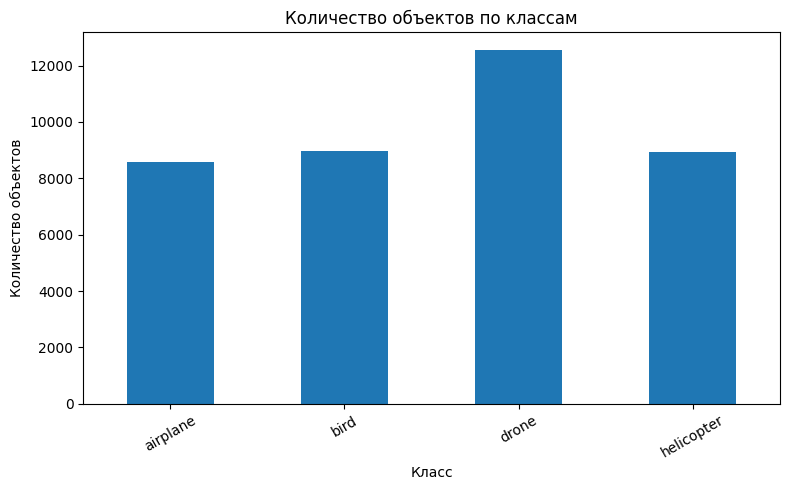

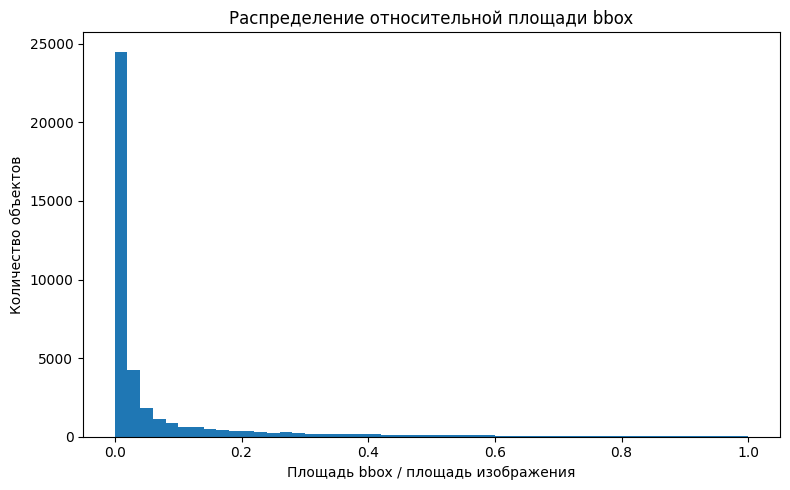

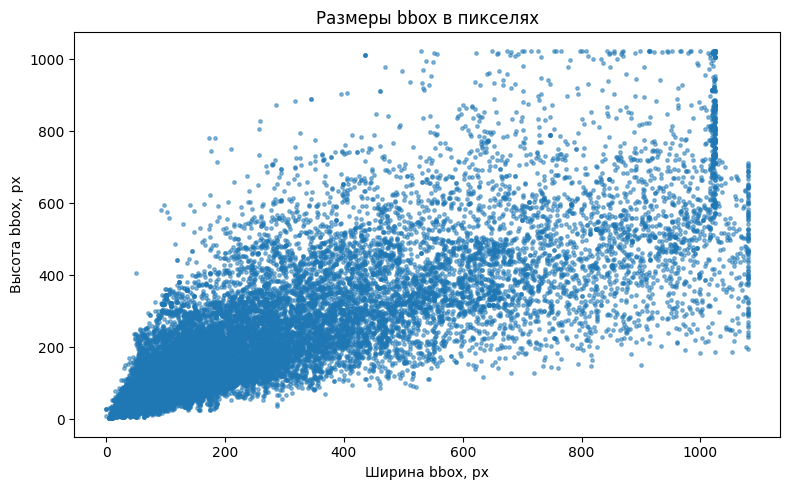

In [ ]:

if not bbox_df.empty:
    plt.figure(figsize=(8, 5))
    class_summary.set_index("class_name")["total"].plot(kind="bar")
    plt.title("Количество объектов по классам")
    plt.xlabel("Класс")
    plt.ylabel("Количество объектов")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / "objects_by_class.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(bbox_df["relative_area"], bins=50)
    plt.title("Распределение относительной площади bbox")
    plt.xlabel("Площадь bbox / площадь изображения")
    plt.ylabel("Количество объектов")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / "bbox_relative_area_hist.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(bbox_df["bbox_width_px"], bbox_df["bbox_height_px"], s=6, alpha=0.5)
    plt.title("Размеры bbox в пикселях")
    plt.xlabel("Ширина bbox, px")
    plt.ylabel("Высота bbox, px")
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / "bbox_width_height_scatter.png", dpi=200)
    plt.show()

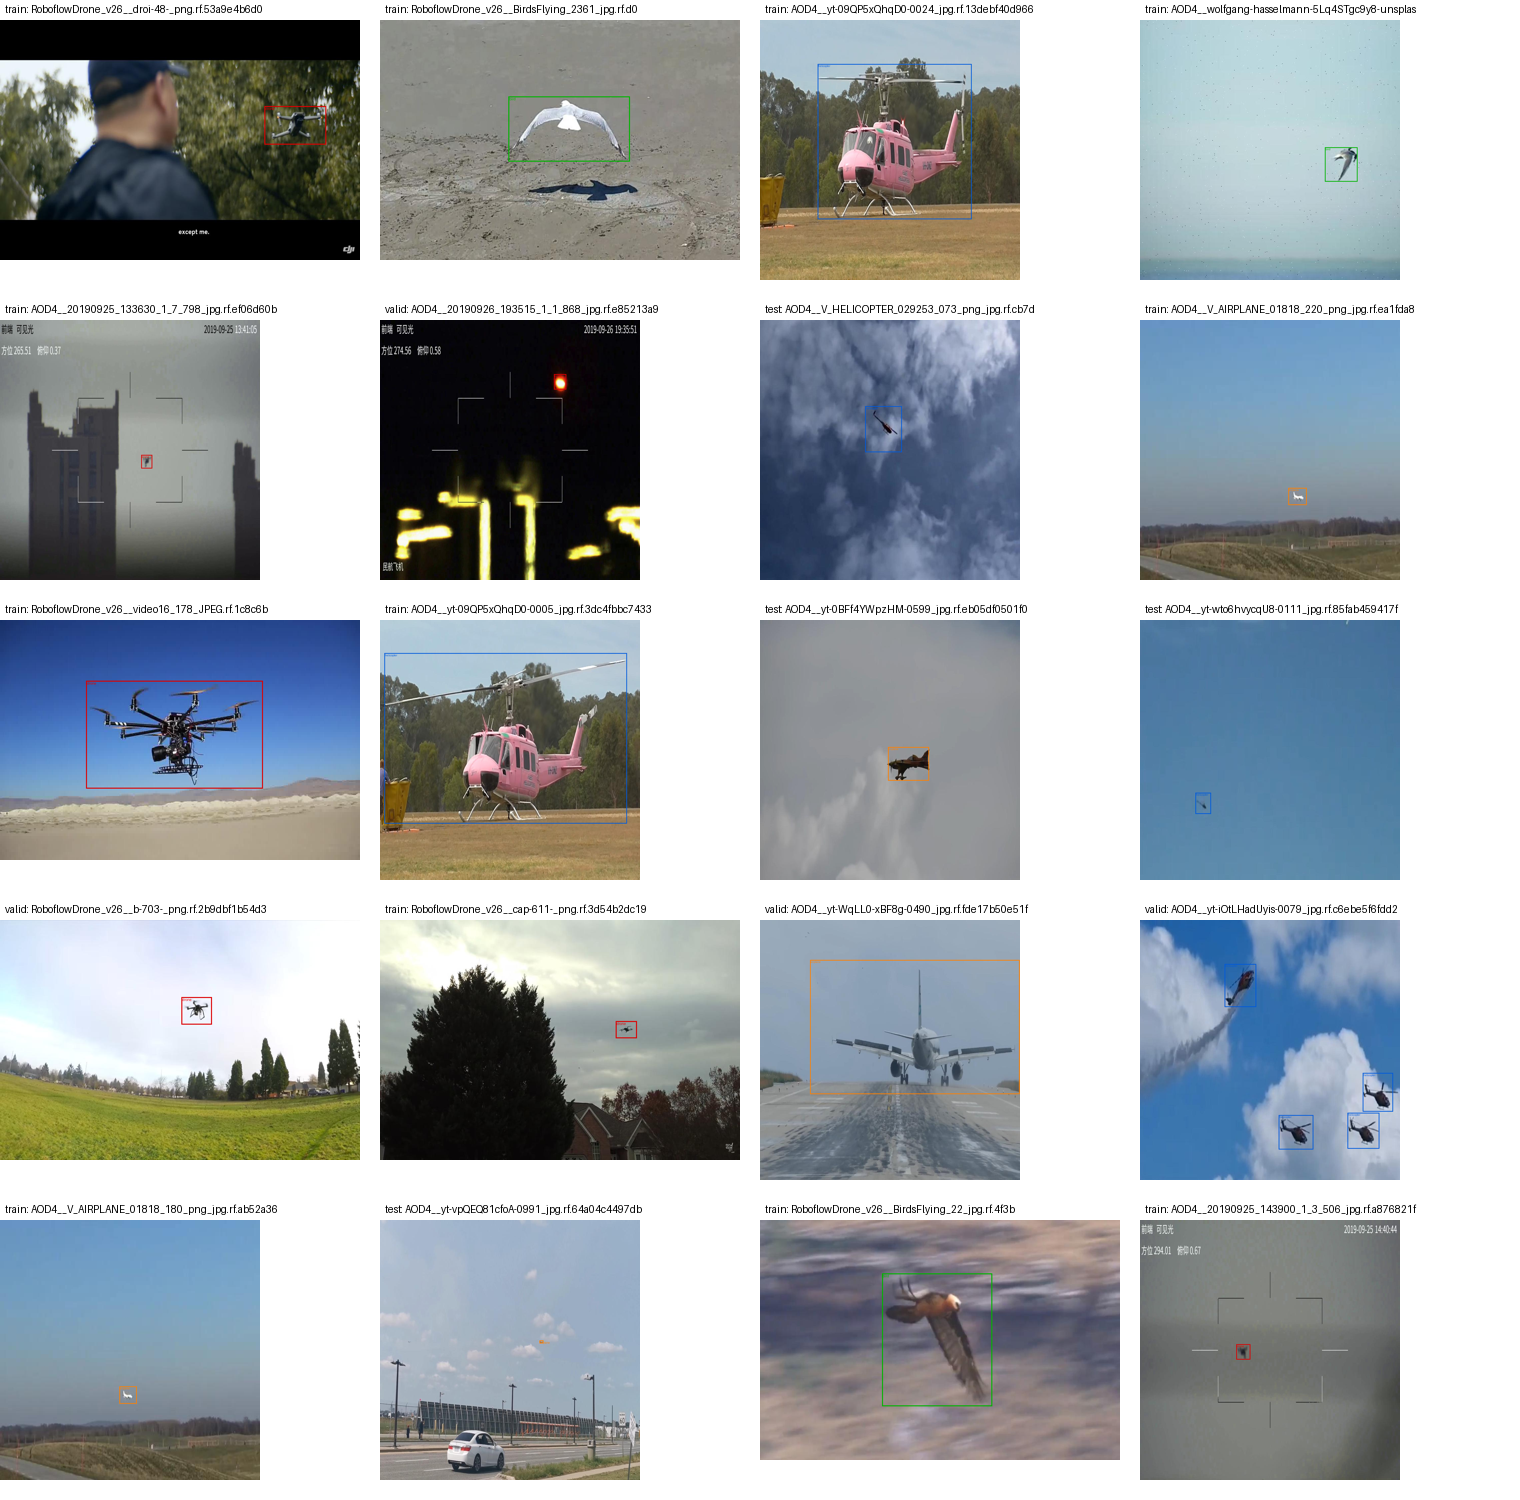

In [ ]:


CLASS_COLORS = {
    0: (255, 128, 0),
    1: (0, 180, 0),
    2: (220, 0, 0),
    3: (0, 90, 220),
}

def draw_yolo_boxes(image_path: Path, label_path: Path, max_size=(360, 260)):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    draw = ImageDraw.Draw(image)
    objects, _ = parse_yolo_label(label_path, CANONICAL_NAMES)
    for obj in objects:
        x1 = (obj["xc"] - obj["w"] / 2) * w
        y1 = (obj["yc"] - obj["h"] / 2) * h
        x2 = (obj["xc"] + obj["w"] / 2) * w
        y2 = (obj["yc"] + obj["h"] / 2) * h
        color = CLASS_COLORS.get(obj["class_id"], (255, 0, 255))
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1 + 2, y1 + 2), CANONICAL_NAMES[obj["class_id"]], fill=color)
    image.thumbnail(max_size)
    return image

sample = []
for split in SPLITS:
    for img_path in get_all_images(MERGED_ROOT / "images" / split):
        lbl_path = MERGED_ROOT / "labels" / split / f"{img_path.stem}.txt"
        sample.append((split, img_path, lbl_path))

random.shuffle(sample)
sample = sample[:20]
cols = 4
cell_w, cell_h = 380, 300
rows = (len(sample) + cols - 1) // cols
grid = Image.new("RGB", (cols * cell_w, rows * cell_h), "white")
draw = ImageDraw.Draw(grid)

for i, (split, img, lbl) in enumerate(sample):
    vis = draw_yolo_boxes(img, lbl)
    x = (i % cols) * cell_w
    y = (i // cols) * cell_h
    grid.paste(vis, (x, y + 20))
    draw.text((x + 5, y + 3), f"{split}: {img.name[:45]}", fill=(0, 0, 0))

grid.save(ANALYSIS_DIR / "sample_markup_grid.jpg", quality=92)
display(grid)